In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
from sklearn.model_selection import train_test_split

## Opgave 1

In [44]:
# Indlæs datasæt
# Når I har lavet opgaverne med dette datasæt kan I prøv andre datasæt fra kaggle: https://www.kaggle.com/datasets?fileType=csv
housing = pd.read_csv("housing.csv")

# Fjern missing values 
housing = housing.dropna()

# Se de første par rækker
print(housing.head())

# Undersøg datatyper og manglende værdier
print(housing.info())

# Beskrivende statistik
print(housing.describe())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data

## Opgave 2

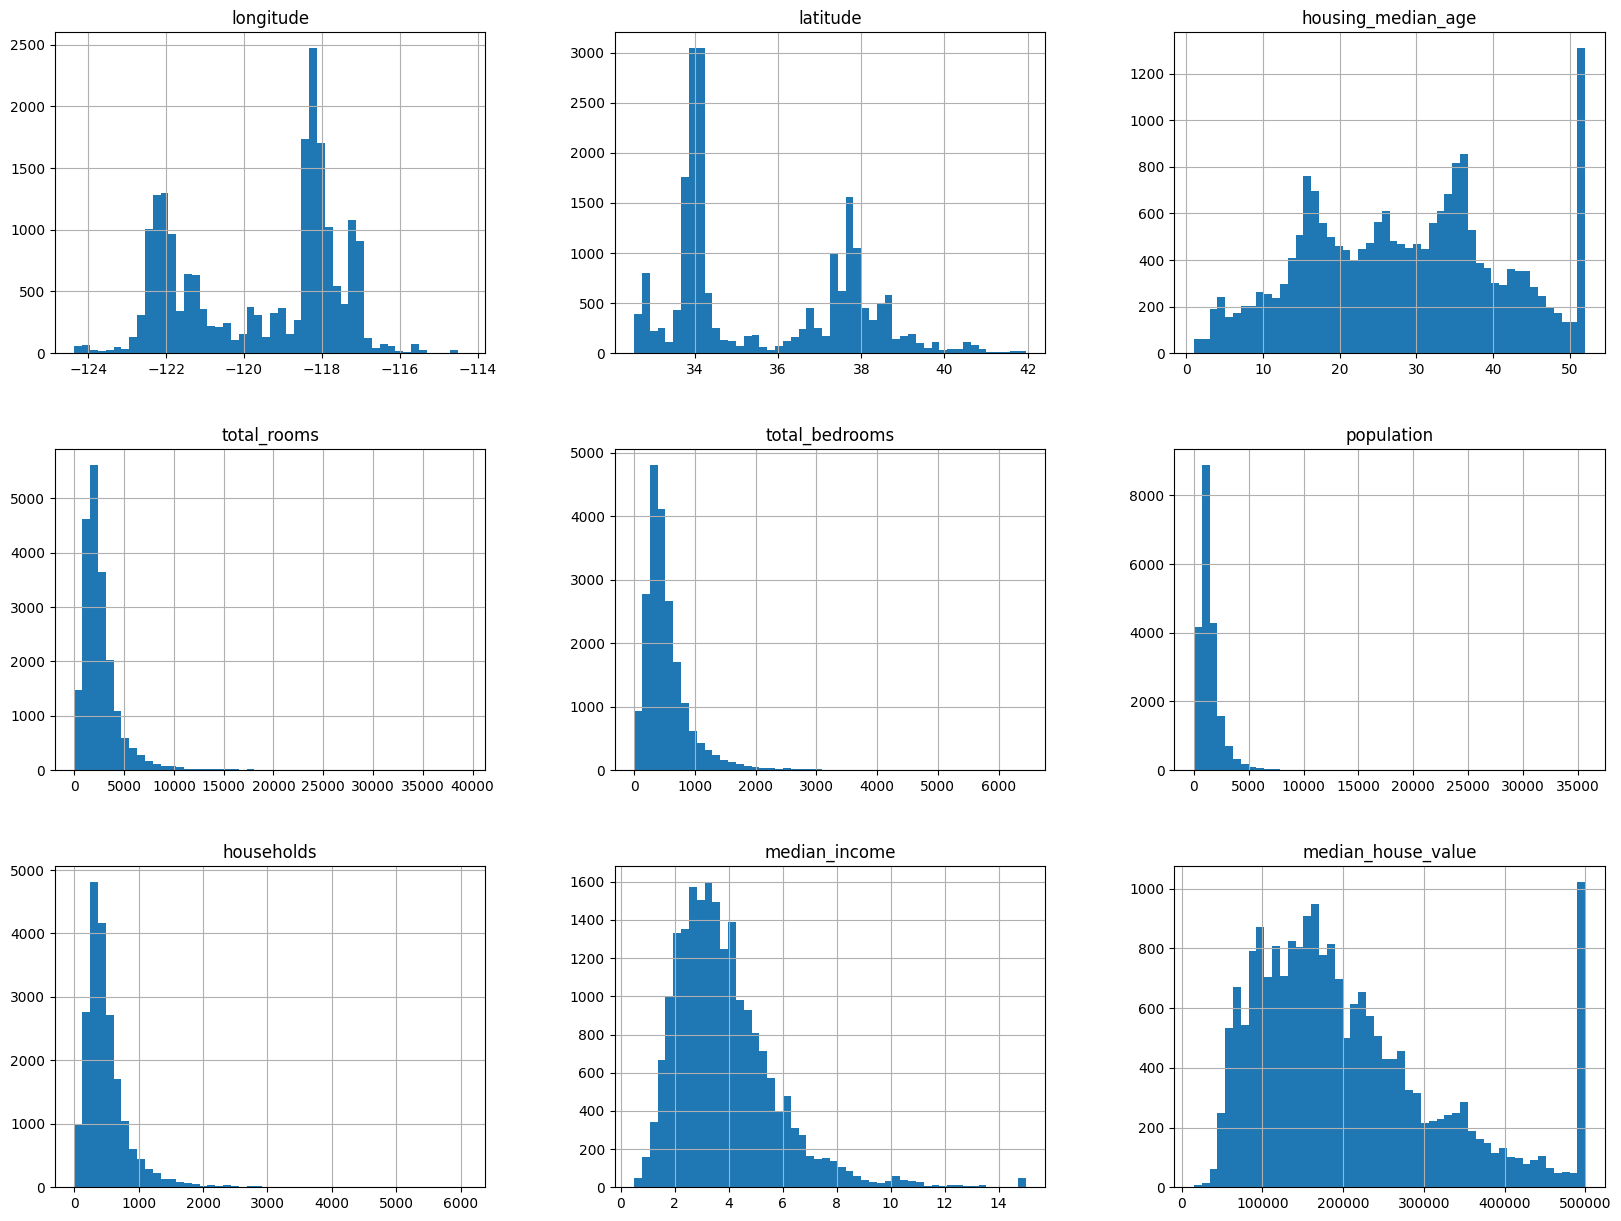

In [45]:
housing.hist(bins=50, figsize=(20,15))
plt.show()

## Opgave 3

In [46]:
# Opret rooms_cat på hele DataFrame før split
housing["rooms_cat"] = pd.cut(housing["total_rooms"],
                               bins=[0., 5000, 10000, np.inf],
                               labels=[0, 1, 2])
test_size = 0.2

# Random split
train_set, test_set = train_test_split(housing, test_size=test_size, random_state=42)
# Stratified split (brug samme kolonne)
strat_train_set, strat_test_set = train_test_split(
    housing, test_size=test_size, stratify=housing["rooms_cat"], random_state=42)

print("Random split (test):")
print(test_set["rooms_cat"].value_counts(normalize=True))

print("Stratified split (test):")
print(strat_test_set["rooms_cat"].value_counts(normalize=True))

# 4) Fjern rooms_cat igen fra de datasæt hvis I vil fortsætte videre uden den
for ds in (train_set, test_set, strat_train_set, strat_test_set):
    ds.drop(columns=["rooms_cat"], inplace=True)

Random split (test):
rooms_cat
0    0.908246
1    0.076829
2    0.014925
Name: proportion, dtype: float64
Stratified split (test):
rooms_cat
0    0.914852
1    0.071201
2    0.013947
Name: proportion, dtype: float64


## Opgave 4

median_house_value    1.000000
median_income         0.688355
total_rooms           0.133294
housing_median_age    0.106432
households            0.064894
total_bedrooms        0.049686
population           -0.025300
longitude            -0.045398
latitude             -0.144638
Name: median_house_value, dtype: float64


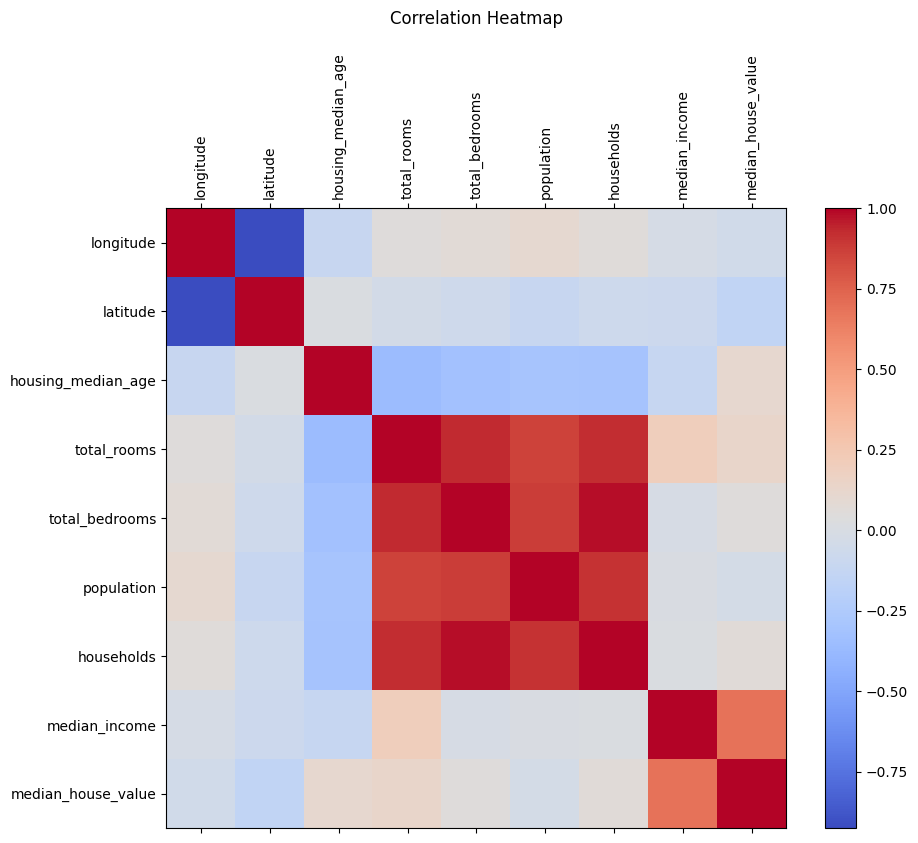

In [47]:
corr_matrix = housing.select_dtypes(include=[np.number]).corr()
print(corr_matrix["median_house_value"].sort_values(ascending=False))

# Plot heatmap
plt.figure(figsize=(10, 8))
plt.matshow(corr_matrix, cmap="coolwarm", fignum=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Heatmap", pad=20)
plt.show()

## Opgave 5

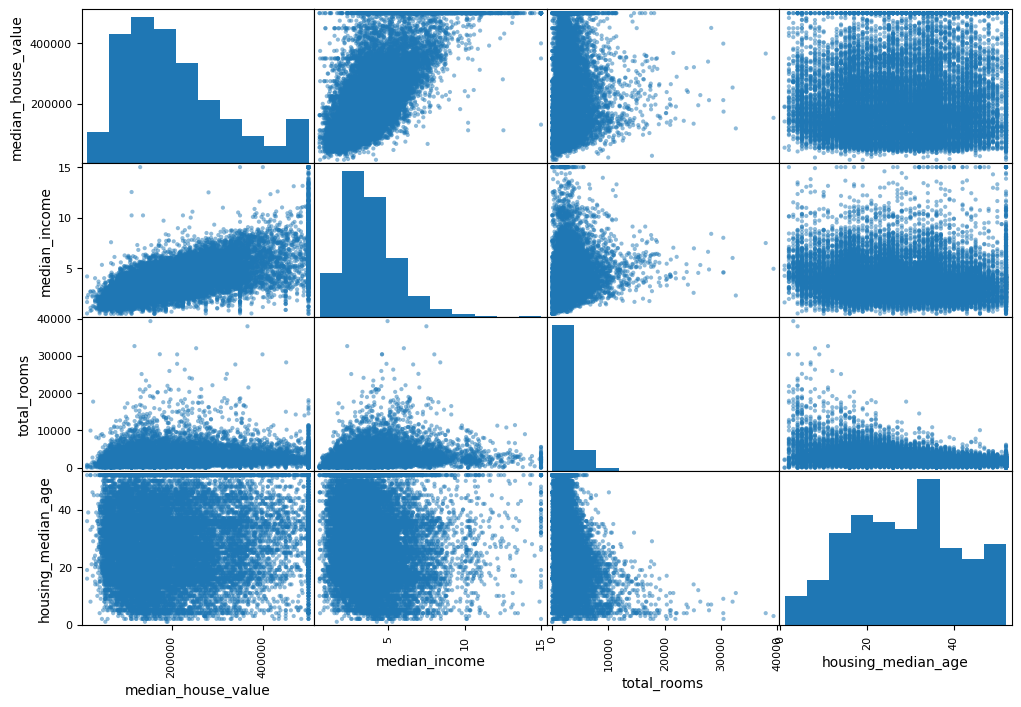

In [48]:
attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]
scatter_matrix(housing[attributes], figsize=(12, 8))
plt.show()